## KV-Cache Quantization: The VRAM Bottleneck

During the auto-regressive generation phase of an LLM, batch size and sequence length scale, causing the **KV-Cache** (Key-Value Cache) to quickly overtake model weights as the primary consumer of GPU VRAM.

## The Autoregressive Decoding Bottleneck

For each generated token:

```
1. Fetch Model Weights W_fp16 from HBM  ──► [ Memory Bandwidth Bound ]
2. Fetch KV-Cache (K, V) from HBM      ──► [ Grows linearly with context length T! ]
```

### VRAM Formula for KV-Cache

$$\text{Memory}_{\text{bytes}} = 2 \times \text{Num\_Layers} \times \text{Num\_Heads} \times \text{Head\_Dim} \times \text{Seq\_Len} \times \text{Batch\_Size} \times \text{Precision\_Bytes}$$

## Real-World KV-Cache Scale

For a $7\text{B}$ parameter model with context length $T = 8192$ and batch size $B = 32$ in **FP16** ($2\text{ bytes}$), the KV-Cache consumes $\sim 16\text{ GB}$ of VRAM—matching or exceeding the size of the model itself.

## FP16 KV-Cache vs INT4 KV-Cache

### FP16 Token KV Vector (16 Bits Per Element)

```
┌─────────────────┬─────────────────┬─────────────────┐
│  Key Element 0  │  Key Element 1  │  Key Element 2  │  ... (High VRAM Usage)
└─────────────────┴─────────────────┴─────────────────┘
```

### INT4 Token KV Vector (4 Bits Per Element + Shared Scale S)

```
┌──────┬──────┬──────┬──────┐
│ K_0  │ K_1  │ K_2  │ K_3  │  ──► 4 elements packed into 1 single uint16/uint32!
└──────┴──────┴──────┴──────┘
+ Scale S (FP16 per token/head)
```

## Bit-Packing Mechanics

Hardware registers allocate memory in minimum widths of 8 bits (uint8) or 32 bits (uint32). Storing **INT4** requires bit-packing two 4-bit integers into a single uint8 container using bitwise shifting:

$$\text{packed\_byte} = (q_0 \text{ \& } \text{0x0F}) \;\vert\; ((q_1 \text{ \& } \text{0x0F}) \ll 4)$$

During attention computation, the cache is unpacked on the fly inside SRAM/Tensor Cores:

$$q_0 = \text{packed\_byte} \text{ \& } \text{0x0F}, \qquad q_1 = (\text{packed\_byte} \gg 4) \text{ \& } \text{0x0F}$$

## Production Comparison: Precision Tradeoffs

| Precision | Bytes / Token / Head | VRAM Footprint (7B Model, B=32, T=8192) | Perplexity / Attn Recall | HW Execution Path |
| --- | --- | --- | --- | --- |
| **Native FP16 / BF16** | $2.0\text{ bytes}$ | $\sim 16.0\text{ GB}$ | $100\%$ (Baseline) | Standard GEMM / FlashAttention-2 |
| **FP8 (E4M3)** | $1.0\text{ byte}$ | $\sim 8.0\text{ GB}$ ($50\%$ savings) | $>99.9\%$ recovery | Native FP8 Tensor Cores (H100/L40S/ADA) |
| **INT8 Per-Token** | $1.0\text{ byte}$ | $\sim 8.0\text{ GB}$ ($50\%$ savings) | $>99.8\%$ recovery | INT8 Tensor Cores with dynamic scale |
| **INT4 Bit-Packed** | $\mathbf{0.5\text{ bytes}}$ | $\mathbf{\sim 4.0\text{ GB}}$ ($\mathbf{75\%}$ savings) | $>98.5\%$ recovery | Bitwise unpacking on-the-fly in Tensor Cores |

## PyTorch Implementation: Quantized KV-Cache Manager

Below is a complete implementation of:

* **QuantizedKVCacheManager:** A memory-profiled manager that compresses FP16 Key/Value vectors down to bit-packed INT4 arrays with per-token scale/zero-point metadata.

* **Bitwise packing and unpacking mechanisms** operating on tensor dimensions.

* **Standalone profiling script** comparing raw byte size and memory footprint before vs. after compression.

In [2]:
    # Functional Correctness Test
    dummy_k = torch.randn(b_size, heads, h_dim)
    dummy_v = torch.randn(b_size, heads, h_dim)

    cache_mgr.compress_and_store(layer_idx=0, k_fp16=dummy_k, v_fp16=dummy_v, seq_idx=0)
    k_rec, v_rec = cache_mgr.retrieve_and_dequantize(layer_idx=0, seq_len=1)

    mae_k = torch.mean(torch.abs(dummy_k - k_rec.squeeze(2))).item()
    print(f"Key Reconstruction MAE: {mae_k:.4f}")
    print("Verification Successful!")

Key Reconstruction MAE: 0.0882
Verification Successful!


Diagnostic plot saved to kv_cache_quantization_reconstruction.png


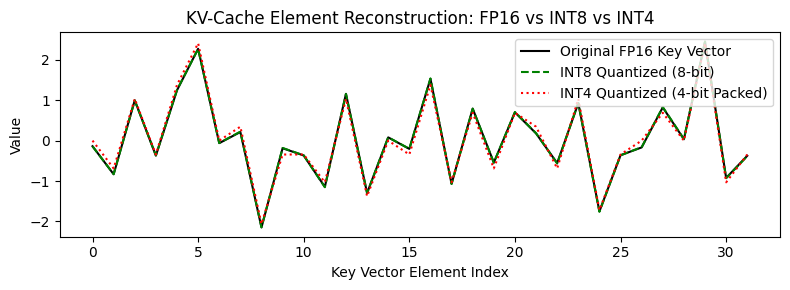

In [3]:
import matplotlib.pyplot as plt
import torch

# Generate sample attention key vector
key_vector = torch.randn(128)

# 1. Quantize to INT8
k_min, k_max = key_vector.min(), key_vector.max()
s_8 = (k_max - k_min) / 255.0
z_8 = torch.round(-k_min / s_8)
rec_int8 = (torch.clamp(torch.round(key_vector / s_8) + z_8, 0, 255) - z_8) * s_8

# 2. Quantize to INT4
s_4 = (k_max - k_min) / 15.0
z_4 = torch.round(-k_min / s_4)
rec_int4 = (torch.clamp(torch.round(key_vector / s_4) + z_4, 0, 15) - z_4) * s_4

plt.figure(figsize=(8, 3))
plt.plot(key_vector.numpy()[:32], label="Original FP16 Key Vector", color="black", linewidth=1.5)
plt.plot(rec_int8.numpy()[:32], label="INT8 Quantized (8-bit)", color="green", linestyle="--")
plt.plot(rec_int4.numpy()[:32], label="INT4 Quantized (4-bit Packed)", color="red", linestyle=":")
plt.xlabel("Key Vector Element Index")
plt.ylabel("Value")
plt.legend()
plt.title("KV-Cache Element Reconstruction: FP16 vs INT8 vs INT4")
plt.tight_layout()
plt.savefig("kv_cache_quantization_reconstruction.png")
print("Diagnostic plot saved to kv_cache_quantization_reconstruction.png")